# Contrôle qualité

###### Equipe pédagogique : P. François, M. Genete, C. Toffano-Nioche, E. Jacquemet, G. Le Corguillé, J. Seiler, D. Puthier, T. Denecker et tout le staff

## Le fichier FastQ

Quelque soit le séquenceur ou l'expérience réalisée, nous obtenons des fichiers FastQ.

Tous se présentent de la même façon :
- Fichier texte contenant les lectures
- 1 lecture/read = 4 lignes
- Chaque lecture est définie par une séquence, un identifiant unique et un score

    @QSEQ32.249996 HWUSI-EAS1691:3:1:17036:13000#0/1 PF=0 length=36
    GGGGGTCATCATCATTTGATCTGGGAAAGGCTACTG
    +
    =.+5:<<<<>AA?0A>;A*A################

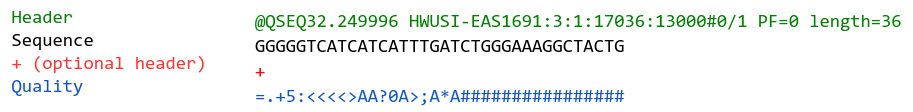

La ligne de header commence toujours par un <code>@</code>.

La ligne de séquence contient le même nombre de caractères que la ligne de qualité mais comment lire cette dernière ?

## Encodage de la qualité

Le score de qualité est encodé au **format ASCII** (American Standard Code for Information Interchange), cela permet qu'une base soit représentée par un caractère unique.

Si nous utilisions des scores qualités directement, il serait impossible de donner la correspondance exacte entre une base et son score.

Par exemple :

    @read1
    ATC
    +
    12523
    
Comment dire si les scores sont de 1, 25 et 23 ou 12, 5 et 23 ?

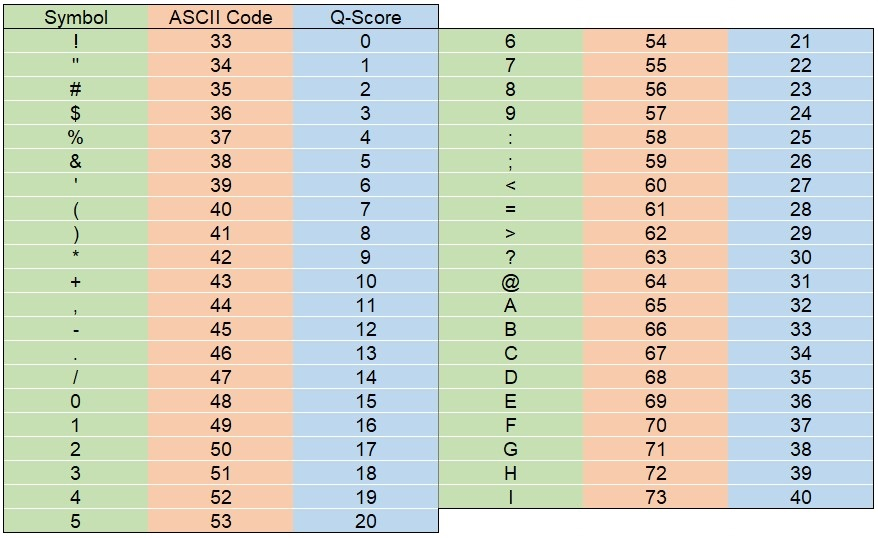

On a donc une correspondance entre chaque symbole et un score qualité, appelé **score Phred**.

Mais comment interpréter ce score ? 

On imagine facilement qu'un score de 40 sera préférable à 0 mais dans quelle mesure ?

Le score Phred peut être converti en probabilité d'erreur, elle même convertible en pourcentage de précision (ou accuracy).

La formule est la suivante :



Où *__Q__* = Le score Phred et *__P__* = La probabilité d'erreur d'identification d'une base.

Voici quelques scores utiles à avoir en tête :
    
| Score de qualité phred | Probabilité d'une identification incorrecte | Précision de l'identification d'une base |
|:---:|:---:|:---:|
| 10 | 1 pour 10 | 90% |
| 20 | 1 pour 100 | 99% |
| 30 | 1 pour 1000 | 99,9% |
| 40 | 1 pour 10000 | 99,99% |

En règle générale, on estime qu'un score doit être supérieur à 20 pour être acceptable.

## L'outil FastQC

Quand nous avons des fichiers avec plus d'un million de lectures, faisant par exemple chacune 150 paires de bases, cela ferait plus de 150 millions de scores qualité à vérifier... Hors de question de le faire à la main, donc.

C'est là que l'outil FastQC nous vient en aide !

Il permet d'obtenir un fichier HTML résumant l'ensemble des informations nécessaires pour estimer si notre run s'est bien passé et si notre échantillon possède des lectures de bonne qualité.

Tentons ensemble d'en saisir le contenu. Vous pouvez cliquer sur ce lien pour visualiser un [rapport complet](https://ifb-elixirfr.github.io/LinuxEBAII/data/siNT_ER_E2_r3_chr21_fastqc.html)

On note tout d'abord que devant chaque section, se trouve un code couleur : 

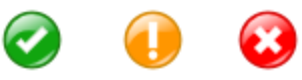

Attention, selon le type de séquençage effectué, cette information n'est pas toujours pertinente.

### _Basic Statistics_ :

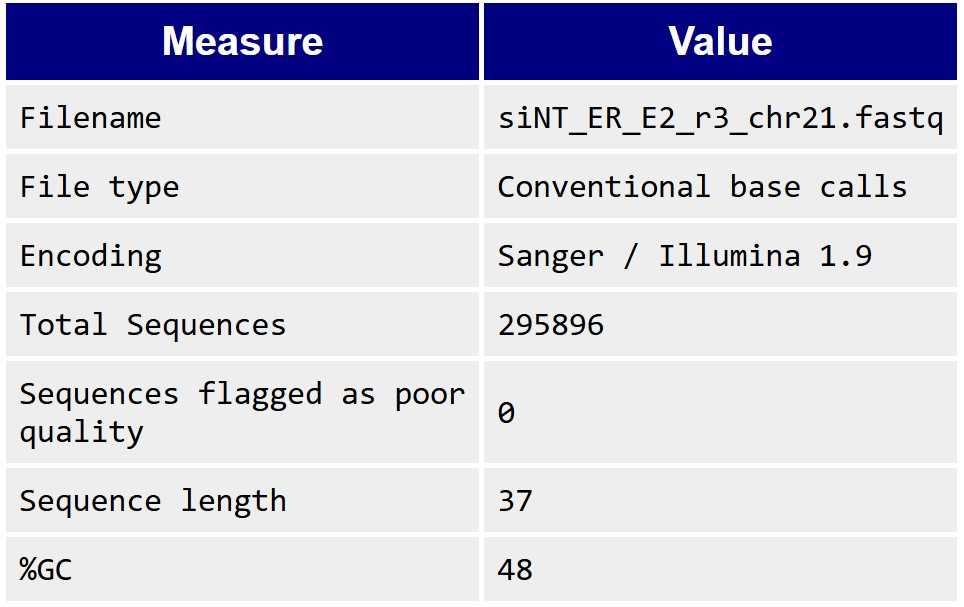

Explication :

Ce tableau récapitule les informations générales de mon échantillon. Ses valeurs dépendent surtout de mon espèce séquencée. Il ne peut jamais être en "erreur" ou en "warning", vous êtes les seuls à pouvoir l'évaluer.

### _Per base Sequence Quality_ :

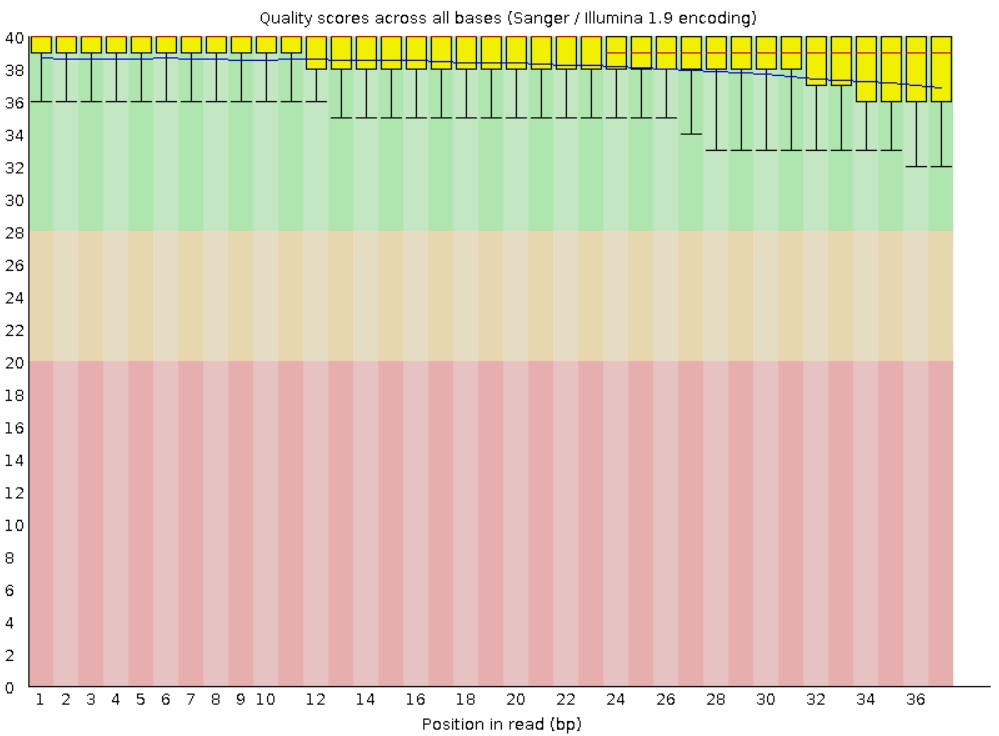

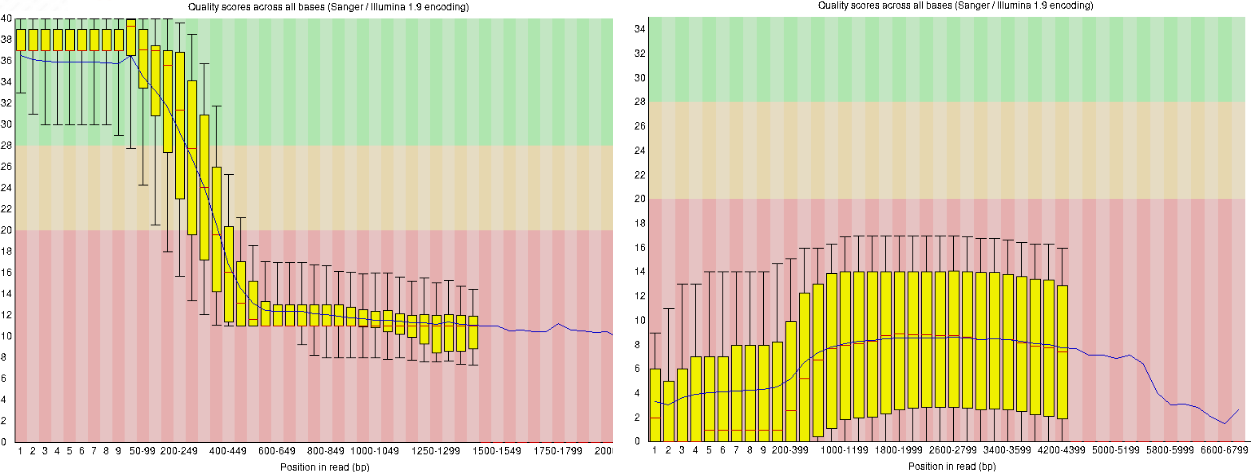

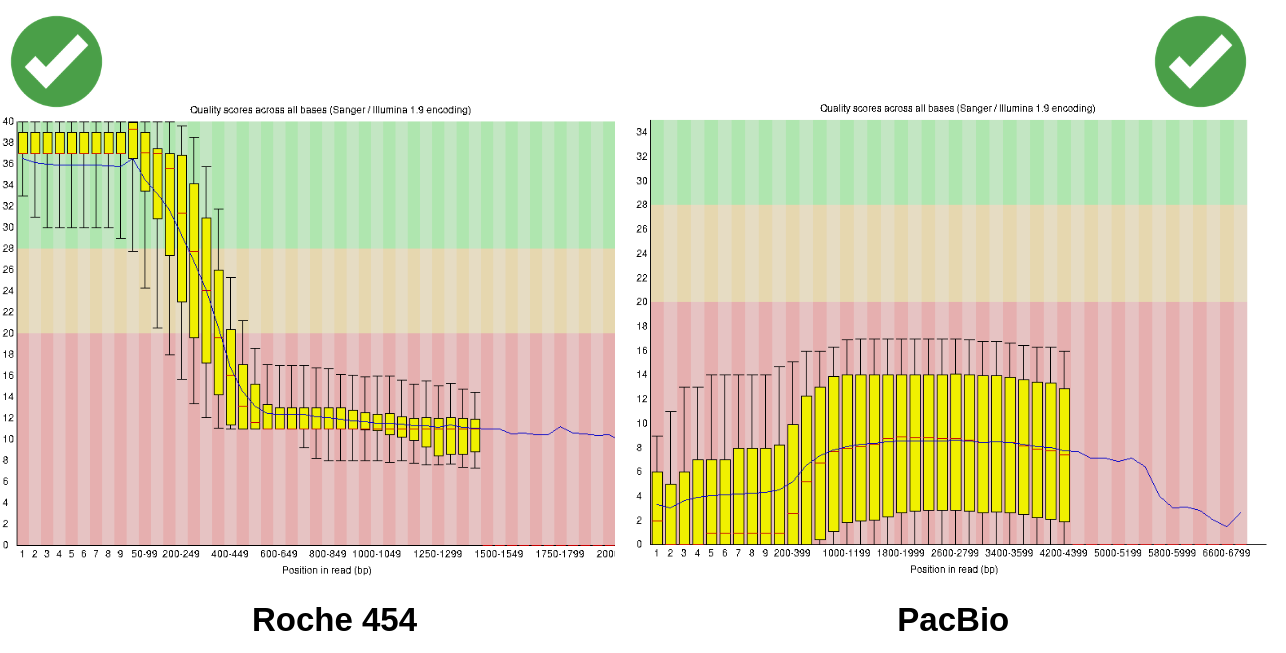

Explication :

Ce graphe montre une vue globale des valeurs de qualité de chacune des bases des lectures. 

Pour chaque position sur le read (axe des abscisses), on obtient une boîte à moustache des qualités. 
- En rouge on trouve la médiane 
- En bleu, la moyenne
- En jaune, l'intervalle inter-quartile (25-75%)
- Les moustaches supérieures et inférieures représentent respectivement 10 et 90%.

L'axe des ordonnées montre les scores de qualité. L'arrière-plan du graphique divise en 3 couleurs comme guide visuel mais reste à prendre avec précaution. La qualité des lectures sur la plupart des plateformes se dégradera à mesure que le séquençage progresse, il est donc courant de voir des qualités passer dans la zone orange vers la fin des lectures.

<div class="alert alert-block alert-warning">
Un avertissement sera émis si le quartile inférieur pour n'importe quelle base est inférieur à 10, ou si la médiane pour n'importe quelle base est inférieure à 25.
</div>

<div class="alert alert-block alert-danger">
Ce module signalera un échec si le quartile inférieur pour n'importe quelle base est inférieur à 5 ou si la médiane pour n'importe quelle base est inférieure à 20.
</div>

### _Per Tile Sequence Quality_

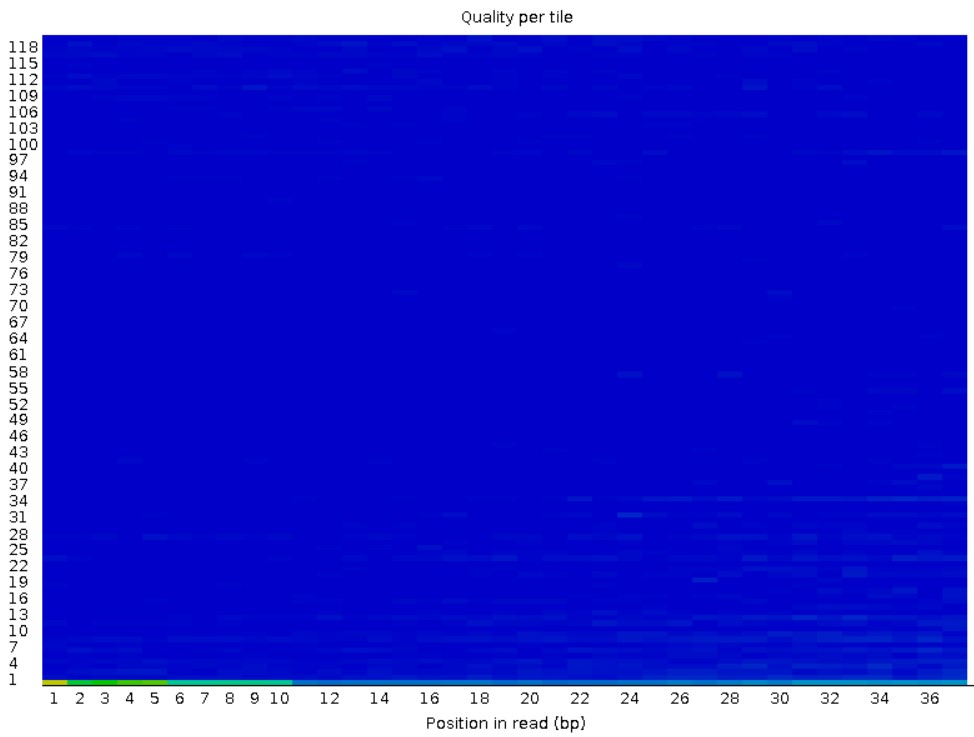

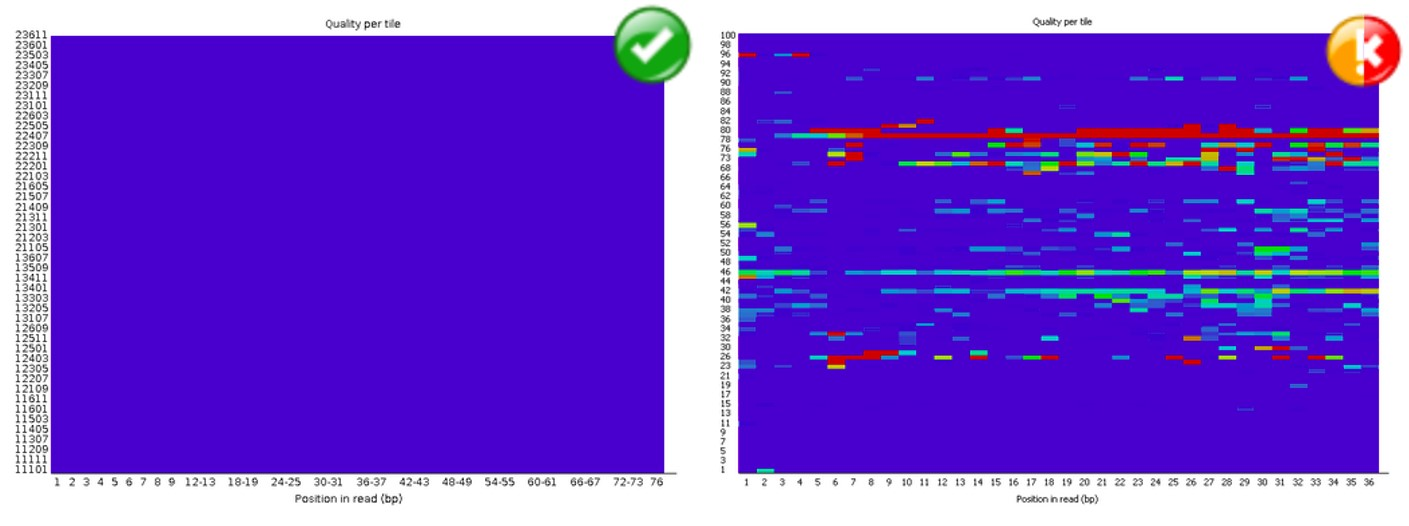

Explication :

Le graphique montre la qualité moyenne pour chaque tuile par rapport aux autres et à chaque instant du séquençage. Les couleurs vont de bleu à rouge, les couleurs froides représentant les positions où la qualité est à la moyenne ou au-dessus pour cette case par rapport aux autres au même instant de séquençage. A l'inverse, les couleurs chaudes indiquent qu'une tuile a des qualités inférieures à celles des autres tuiles. Dans l'exemple ci-dessus à droite, vous pouvez voir que certaines tuiles montrent constamment une mauvaise qualité. Un bon graphique devrait être entièrement bleu.

<div class="alert alert-block alert-warning">
Ce module émettra un avertissement si une tuile montre un score moyen de Phred supérieur de plus de 2 par rapport à la moyennepour cet instant de séquençage à travers toutes les tuiles. 
</div>

<div class="alert alert-block alert-danger">
Ce module émettra un échec si une tuile montre un score moyen de Phred supérieur de plus de 5 par rapport à la moyenne pour cet instant de séquençage à travers toutes les tuiles.
</div>

## _Per Sequence Quality Scores_

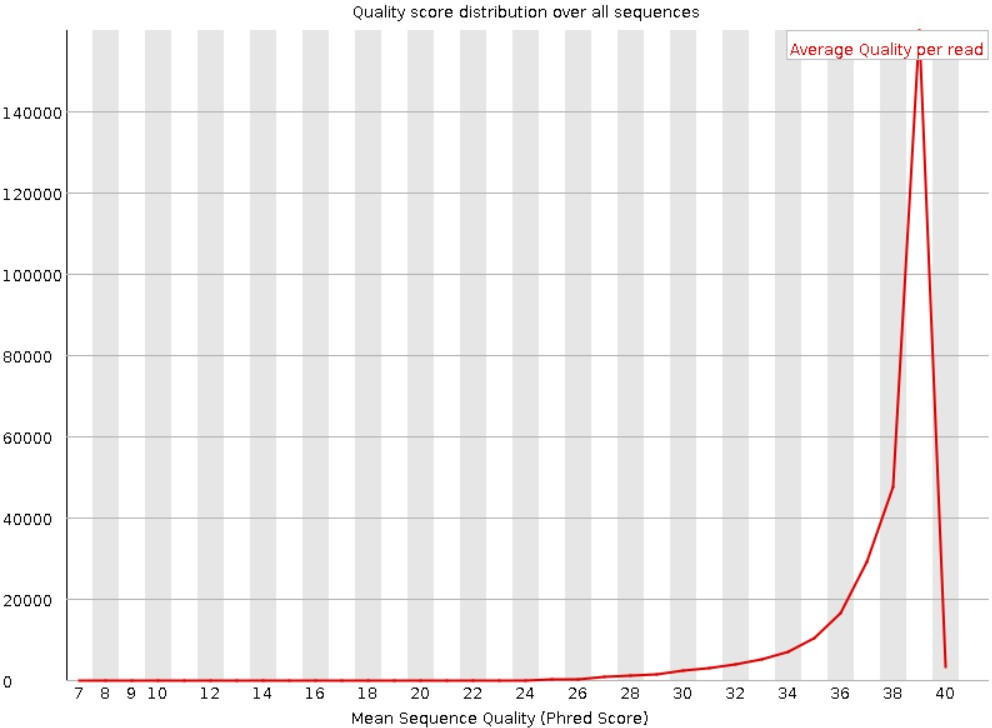

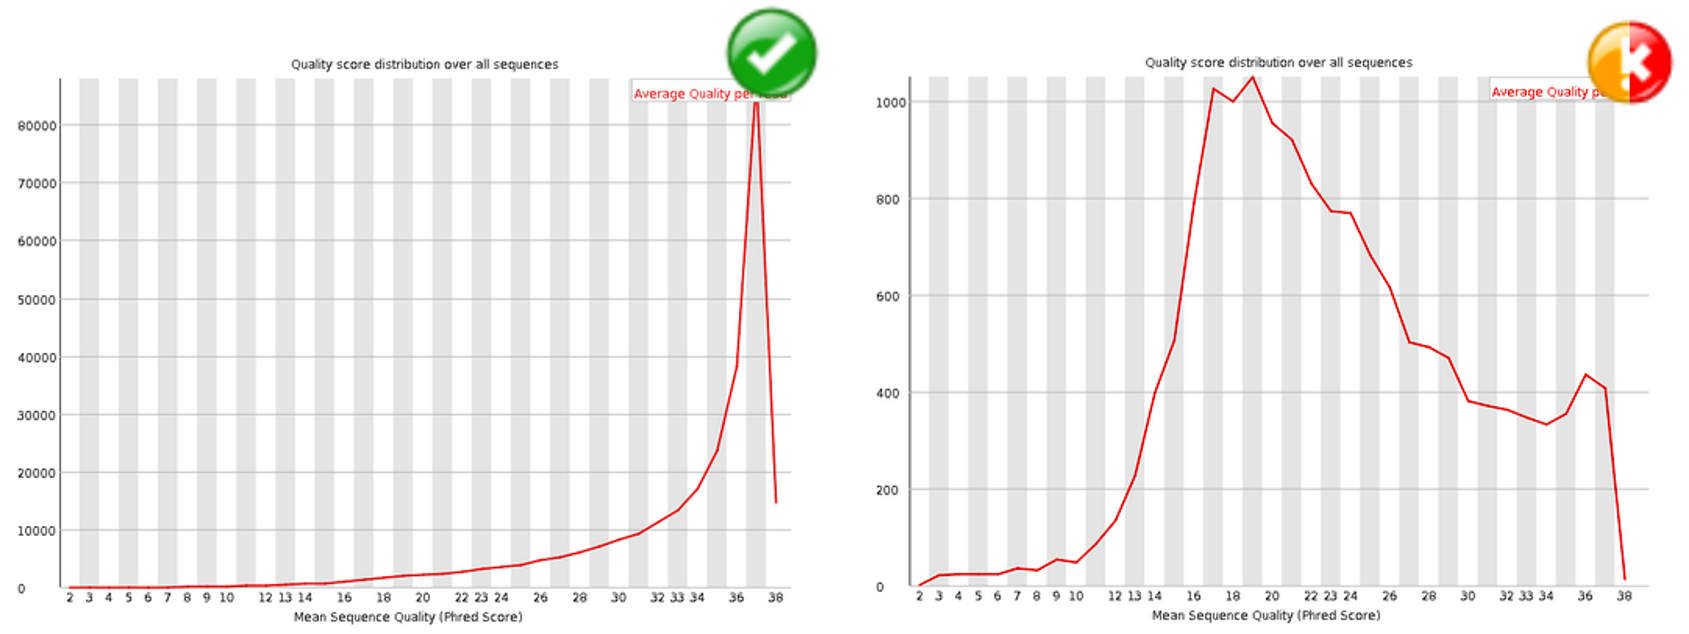

Explication :

Le Per sequence quality scores permet de voir si un sous-ensemble de nos séquences a des valeurs de qualité plus faibles que le reste de nos reads. Il arrive souvent qu'un sous-ensemble de séquences ait une qualité médiocre (problème de prise de l'image sur les bords de flowcell par exemple). Cependant celles-ci ne devraient représenter qu'un petit pourcentage du total des séquences.

Si une proportion significative des séquences d'un run a une qualité globalement faible, cela pourrait indiquer un problème systématique - sur une partie du run notamment.

<div class="alert alert-block alert-warning">
Un avertissement est émis si la qualité moyenne la plus fréquemment observée est inférieure à 27 - cela équivaut à un taux d'erreur de 0,2%.
</div>

<div class="alert alert-block alert-danger">
Une erreur est signalée si la qualité moyenne la plus fréquemment observée est inférieure à 20 - cela équivaut à un taux d'erreur de 1%.
</div>

## _Per Base Sequence Content_

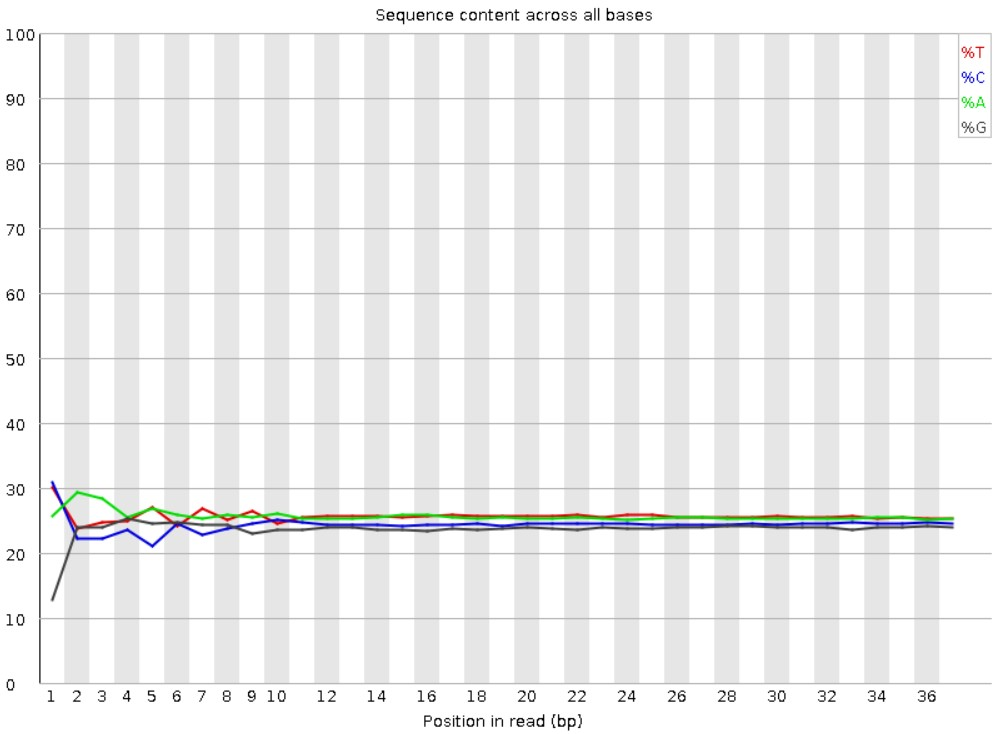

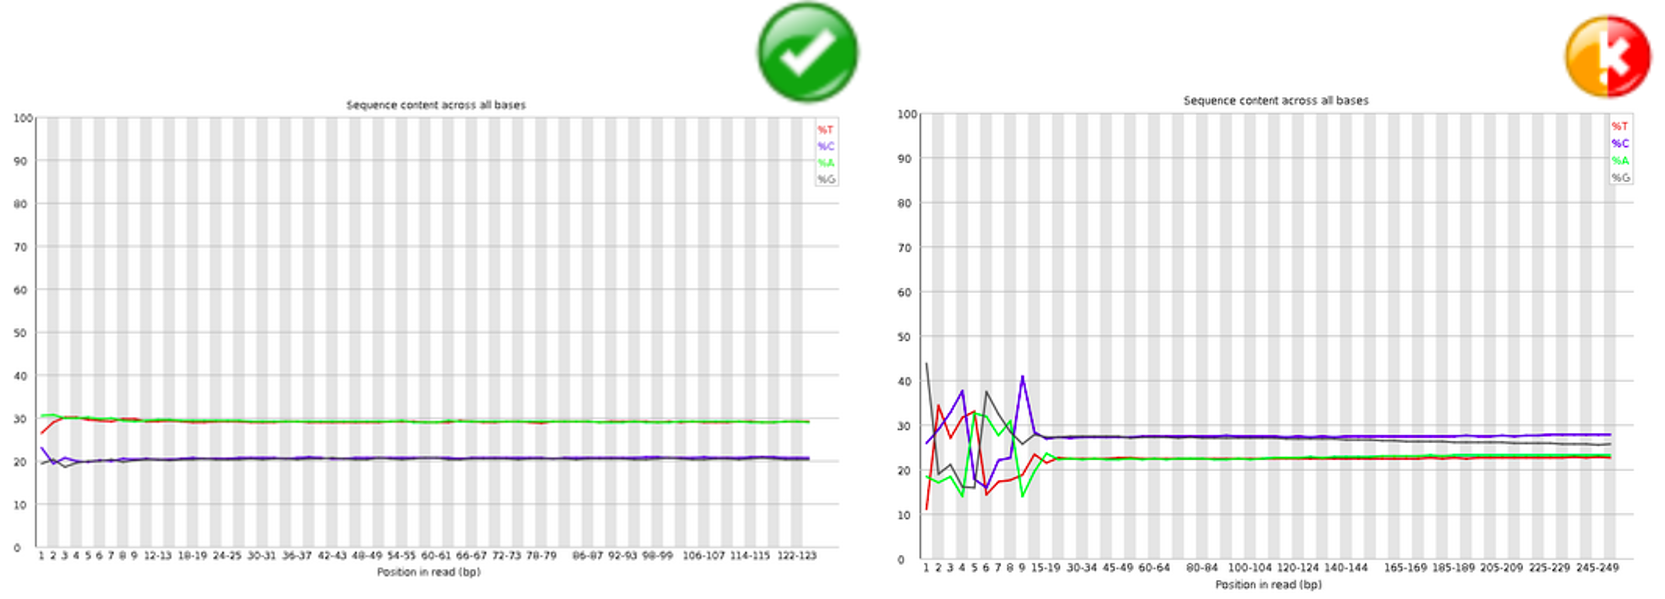

Explication :

Le Per base sequence content trace la proportion à chaque position de chacune des 4 bases.

Dans une librairie aléatoire, on s'attendrait à ce qu'il y ait peu ou pas de différences entre les différentes bases d'une séquence, donc les lignes de ce graphique devraient être parallèles les unes aux autres. En particulier, les lignes de A et T et de C et G doivent être presque parfaitement chevauchantes.

Si vous voyez des biais forts qui changent d'une base à l'autre, cela indique généralement une séquence surreprésentée qui contamine votre librairie. 

<div class="alert alert-block alert-warning">
Ce module émet un avertissement si la différence entre A et T, ou G et C est supérieure à 10 % à n'importe quelle position.
</div>

<div class="alert alert-block alert-danger">
Ce module échouera si la différence entre A et T, ou G et C est supérieure à 20 % à n'importe quelle position.
</div>

## _Per Sequence GC Content_

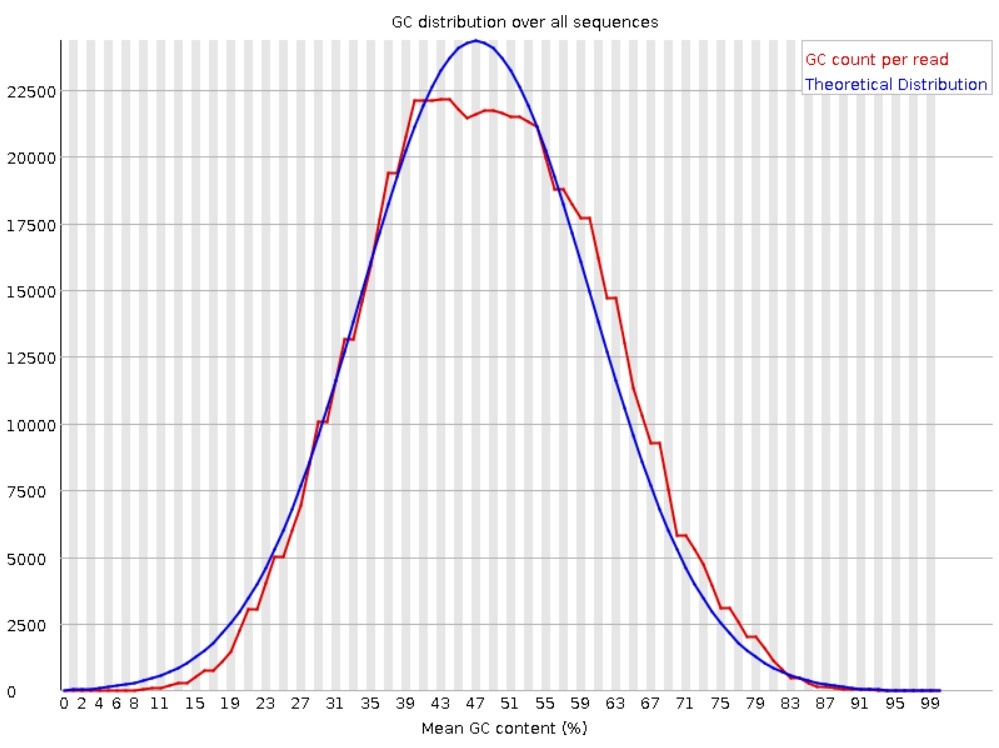

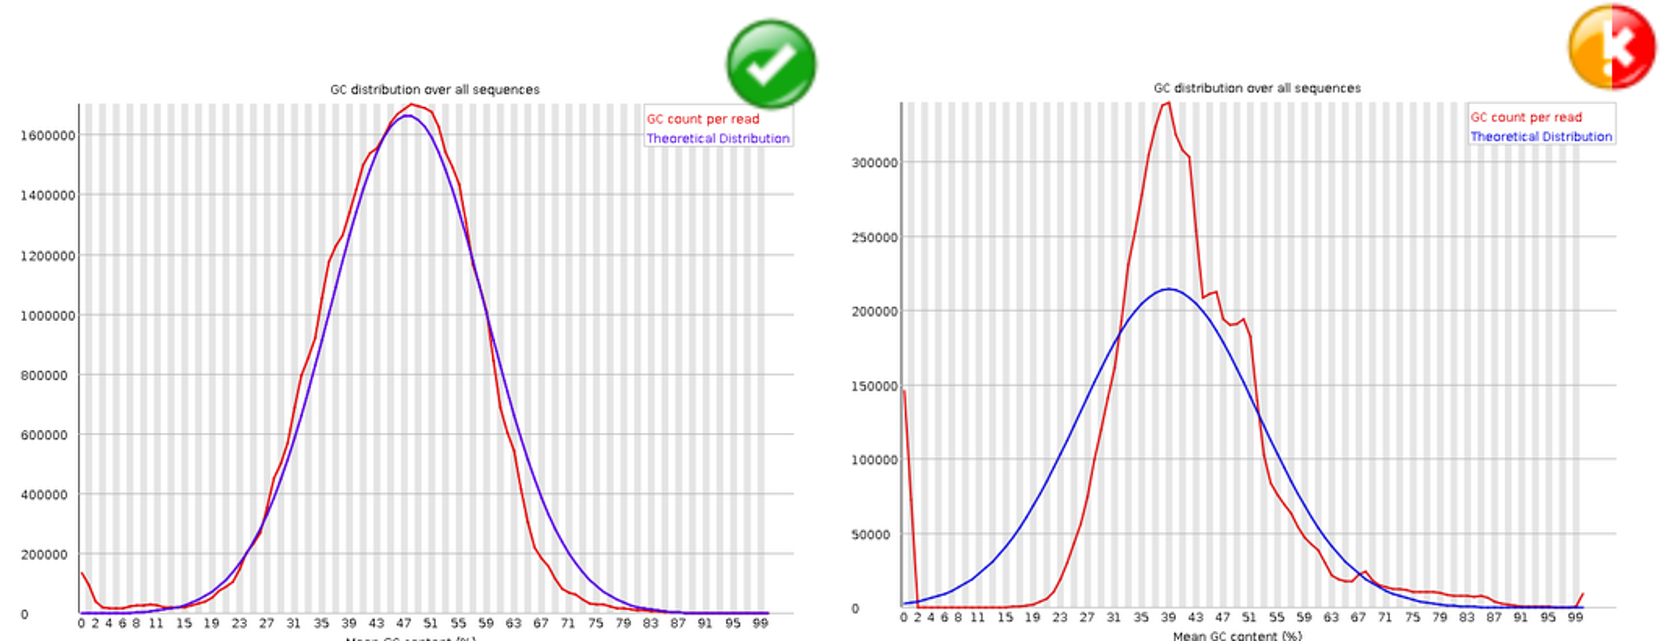

Explication :

Ce module mesure le pourcentage de GC moyen de chaque lecture du fichier et le compare à une distribution normale modélisée de ce %GC. 

Dans une librairie aléatoire, on s'attendrait à voir une distribution normale, où le pic central correspond au pourcentage de GC du génome attendu. Comme le génome de référence n'est pas connu par fastQC, le pourcentage en GC est calculé à partir des données observées et utilisé pour construire une distribution de référence. 

Si la courbe rouge (distribution réelle) présente une forme inhabituelle, cela pourrait indiquer une librairie contaminée par exemple. Une distribution normale qui serait légèrement décalée indique un certain biais systématique. Si c'est le cas, cela ne sera pas signalé comme une erreur par fastQC puisqu'il ne sait pas quelle devrait être la valeur du %GC de votre génome.

<div class="alert alert-block alert-warning">
Un avertissement est émis si la somme des écarts par rapport à la distribution normale représente plus de 15 % des lectures.
</div>

<div class="alert alert-block alert-danger">
Ce module indiquera un échec si la somme des écarts par rapport à la distribution normale représente plus de 30 % des lectures.
</div>

## _Per Base N Content_ 

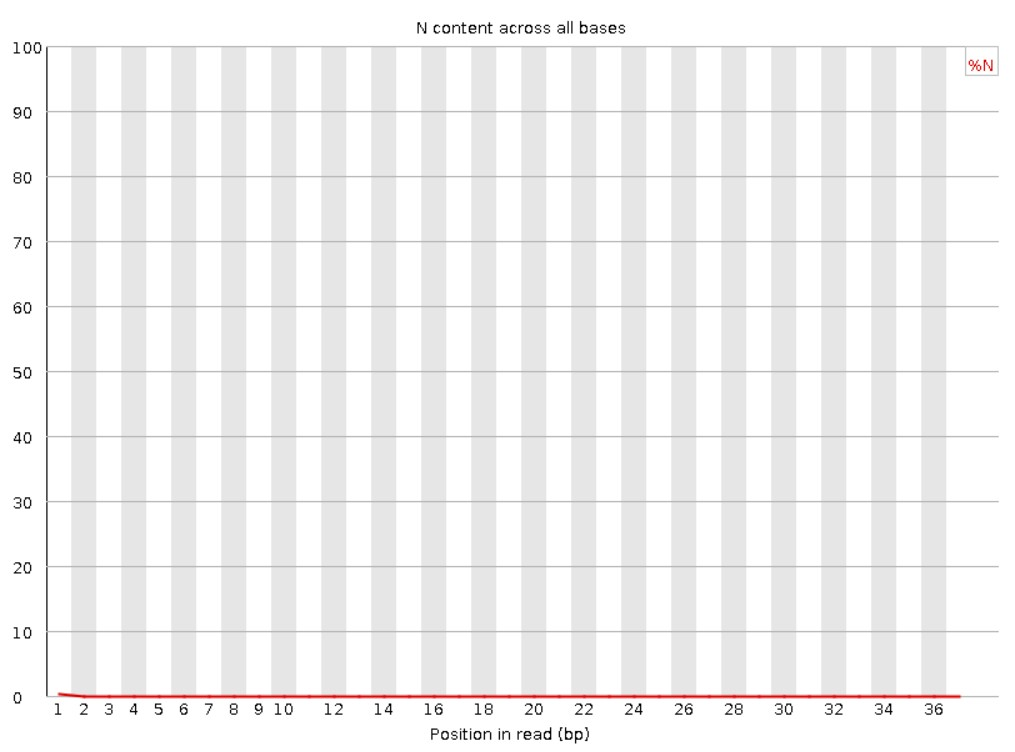

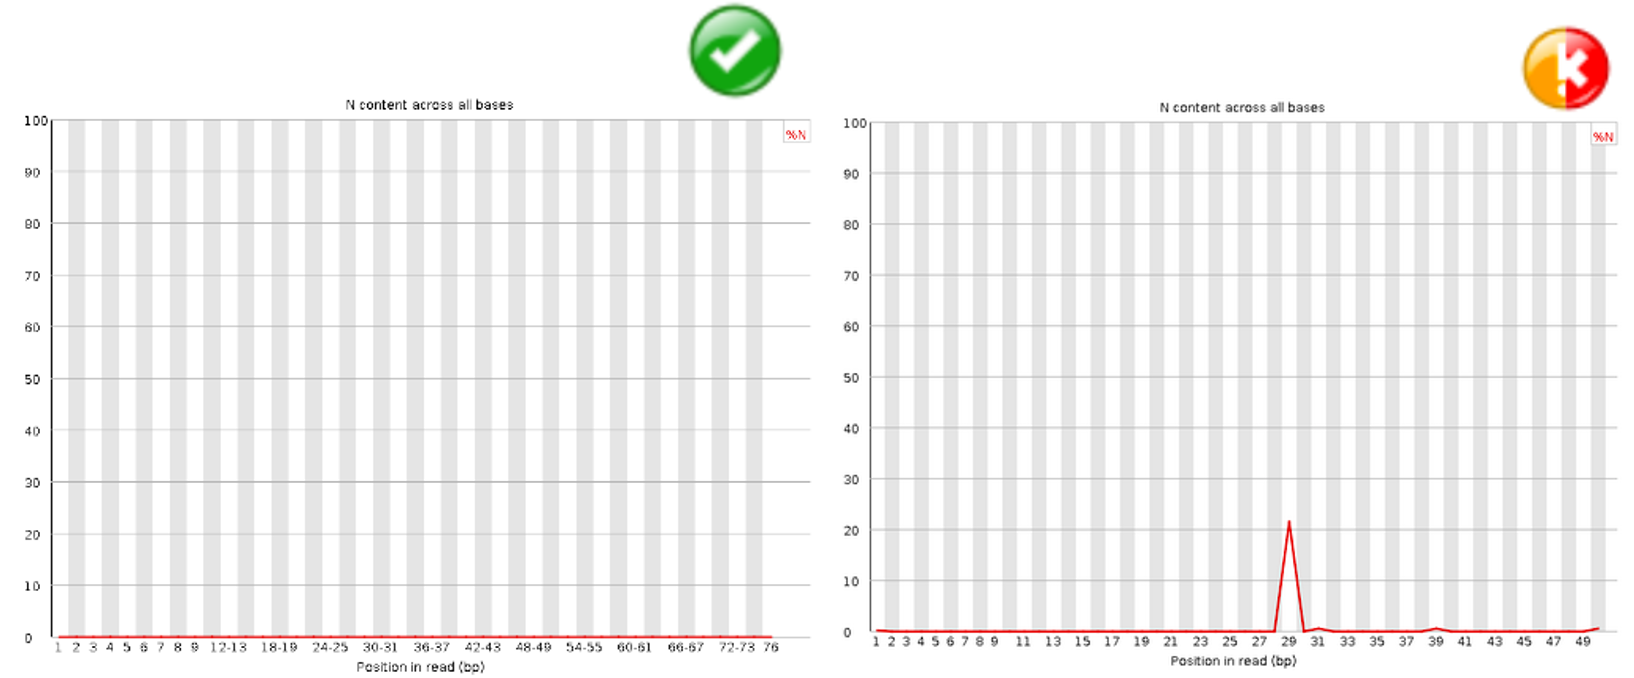

Explication :

Si un séquenceur n'est pas en mesure de lire une base avec suffisamment de confiance, il substituera la base par un N plutôt que d'ajouter une base fausse. Ici nous avons donc la représentation du pourcentage de bases remplacées par des N pour chaque position.

Il n'est pas inhabituel de voir une très faible proportion de N apparaître dans une séquence, en particulier vers la fin d'une séquence (donc du séquençage). Cependant, si cette proportion dépasse quelques pourcents, cela suggère que le séquenceur n'a pas été en mesure d'interpréter un grand nombre de bases.

<div class="alert alert-block alert-warning">
Ce module émet un avertissement si une position montre un contenu en N supérieur à 5 %.
</div>

<div class="alert alert-block alert-danger">
Ce module signalera une erreur si une position montre un contenu en N supérieur à 20 %.
</div>

## _Sequence Length Distribution_

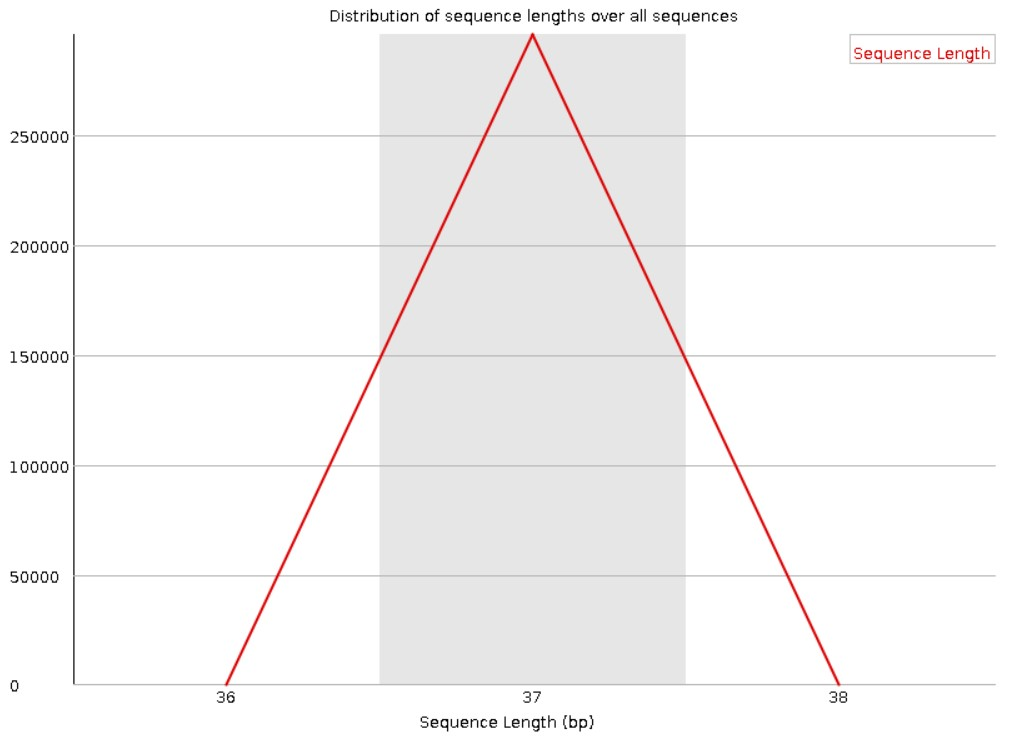

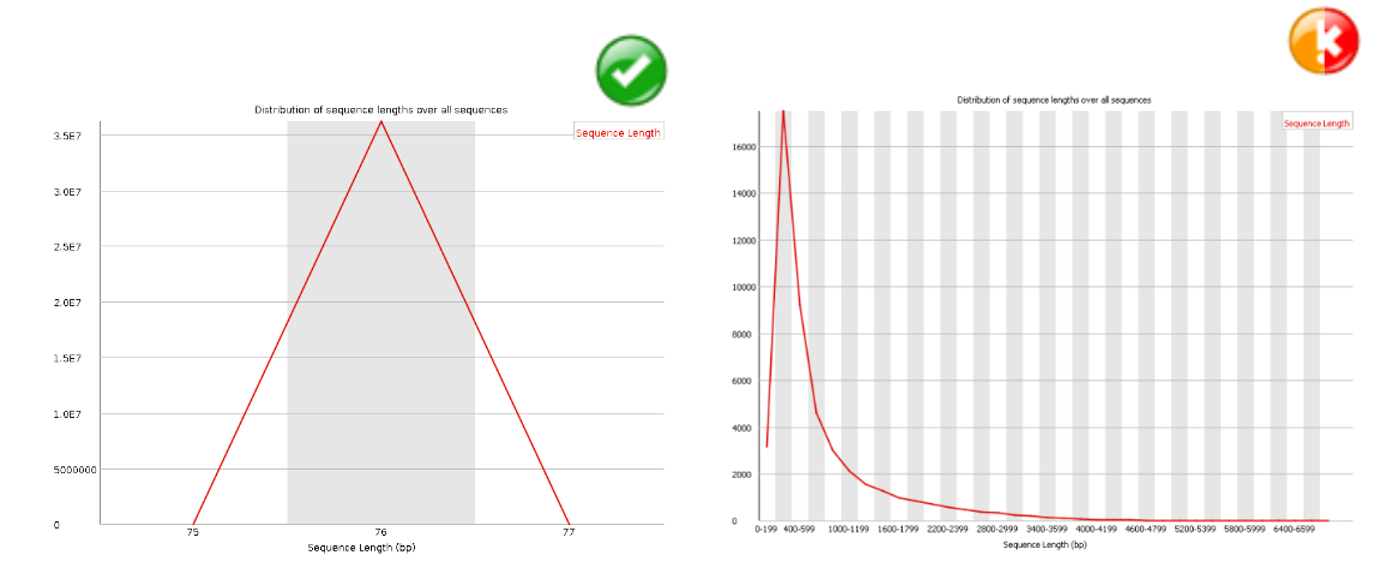

Explication :

Certains séquenceurs à haut débit génèrent des reads de longueur uniforme, mais d'autres peuvent contenir des lectures de longueurs très variées. Même dans les librairies de longueur uniforme, certains pipelines vont tronquer les séquences pour enlever les bases de mauvaise qualité à partir de leur extrémité. Ce module génère un graphique montrant la distribution des tailles de reads dans le fichier analysé. 

Dans de nombreux cas, cela produira un graphique simple montrant un pic à une seule taille, mais pour les fichiers FastQ de longueur variable, cela montrera les quantités relatives de chaque taille différente de reads.

<div class="alert alert-block alert-warning">
Ce module émet un avertissement si toutes les lectures ne sont pas de la même taille.
</div>

<div class="alert alert-block alert-danger">
Ce module signalera une erreur si au moins une séquence est de taille 0.
</div>

## _Duplicate Sequences_

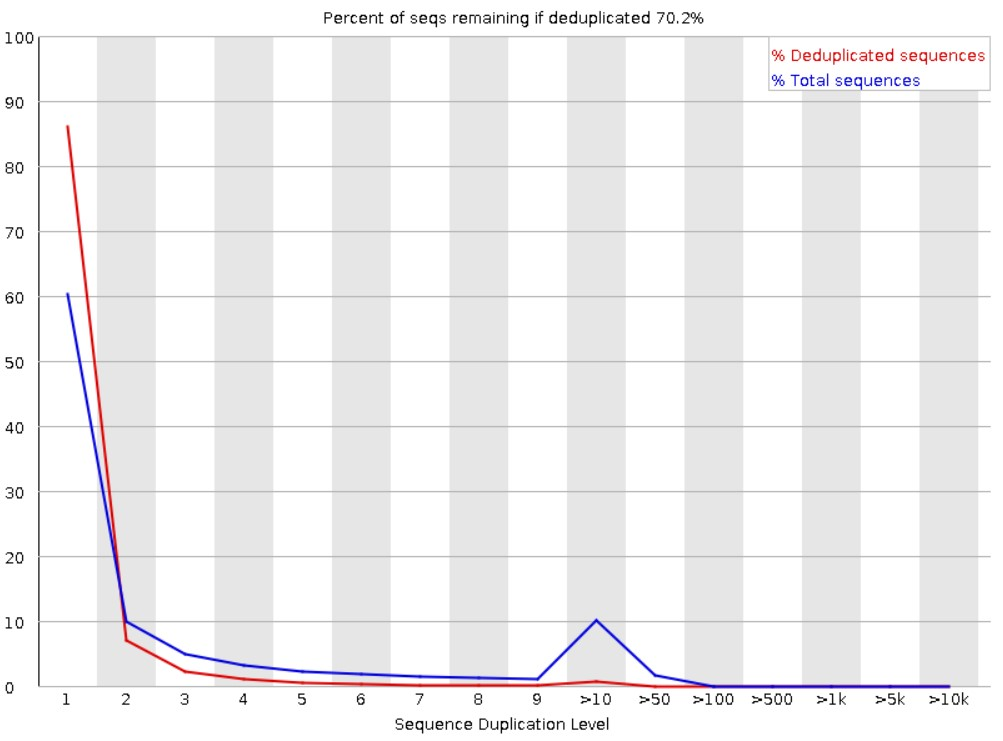

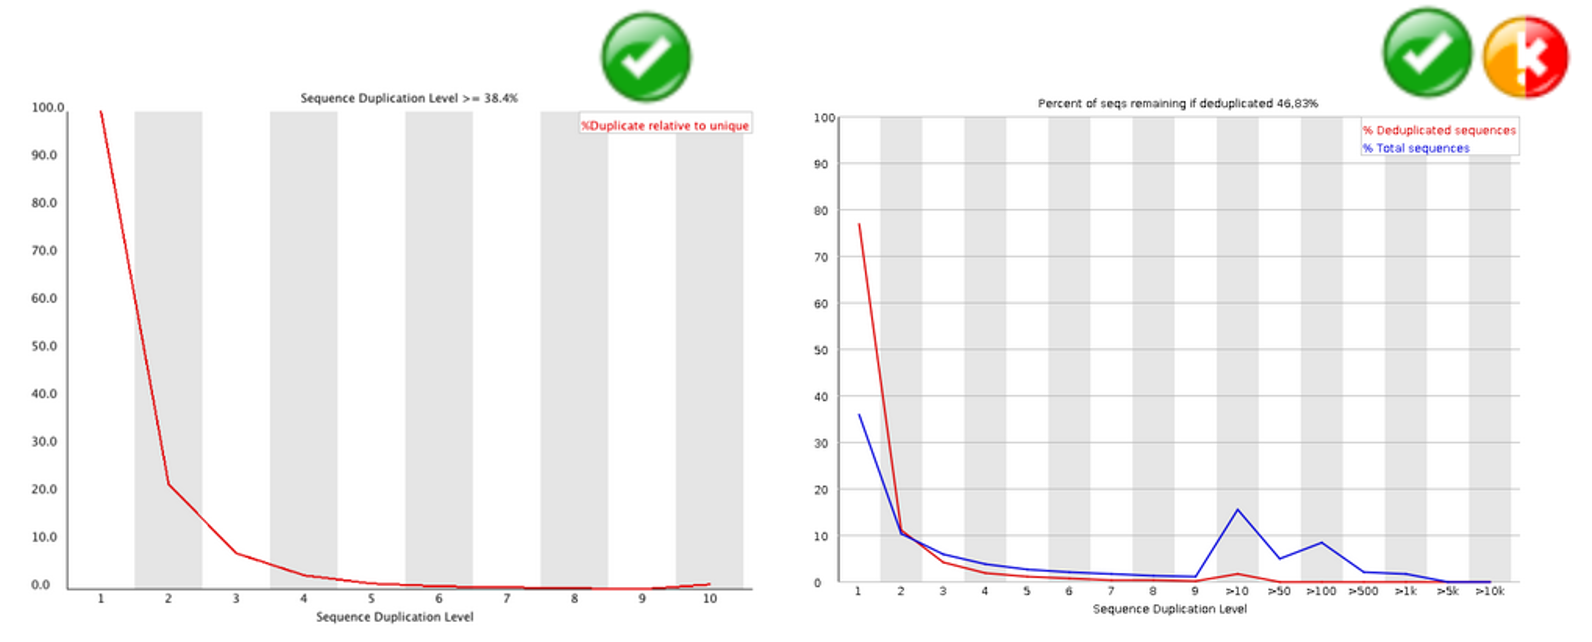

Explication :

Dans une librairie aléatoire, la plupart des séquences n'apparaîtront qu'une seule fois. Un faible niveau de duplication peut indiquer un niveau de couverture très élevé de la séquence cible, mais un niveau élevé de duplication est plus susceptible d'indiquer un biais d'enrichissement (par exemple, une sur-amplification par PCR).

Ce module compte le degré de duplication pour chaque séquence du fichier et crée un graphique montrant le pourcentage de lectures à chaque niveau de duplication.

<div class="alert alert-block alert-warning">
Ce module émet un avertissement si le taux de séquence non-unique est supérieur à 20%.
</div>

<div class="alert alert-block alert-danger">
Ce module signalera une erreur si le taux de séquence non-unique est supérieur à 50%.
</div>

## _Overrepresented Sequences_

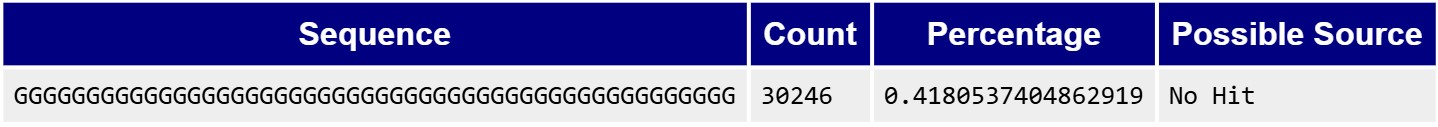

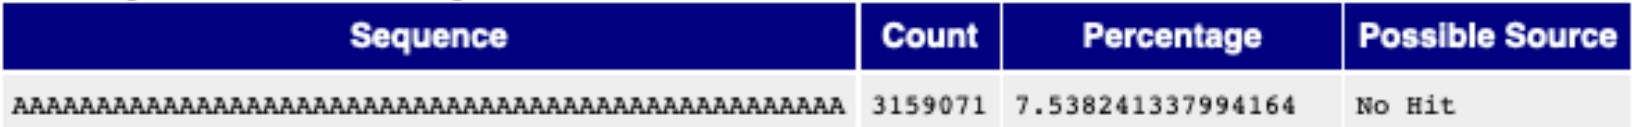

Explication :

Une librairie normale contient un ensemble diversifié de séquences, sans qu'aucune séquence individuelle ne soit sur-représentée face aux autres. 

Trouver une séquence sur-représentée signifie soit qu'elle est très significative sur le plan biologique, soit que la librairie est contaminée, ou n'est pas aussi diversifiée que vous l'aviez prévu. 

Attention, ce module répertorie toutes les séquences qui représentent plus de 0,1 % du total mais pour économiser de la mémoire, seules les séquences qui apparaissent dans les 200 000 premiers reads sont suivies jusqu'à la fin du fichier. Il est donc possible qu'une séquence soit sur-représentée mais qu'elle n'apparaisse pas au début du fichier pour une raison quelconque et puisse donc être manquée par ce module.

<div class="alert alert-block alert-warning">
Ce module émet un avertissement si n'importe quelle séquence est présente à plus de 0,1%.
</div>

<div class="alert alert-block alert-danger">
Ce module signalera une erreur si n'importe quelle séquence est présente à plus de 1%.
</div>

## _Adapter Content_

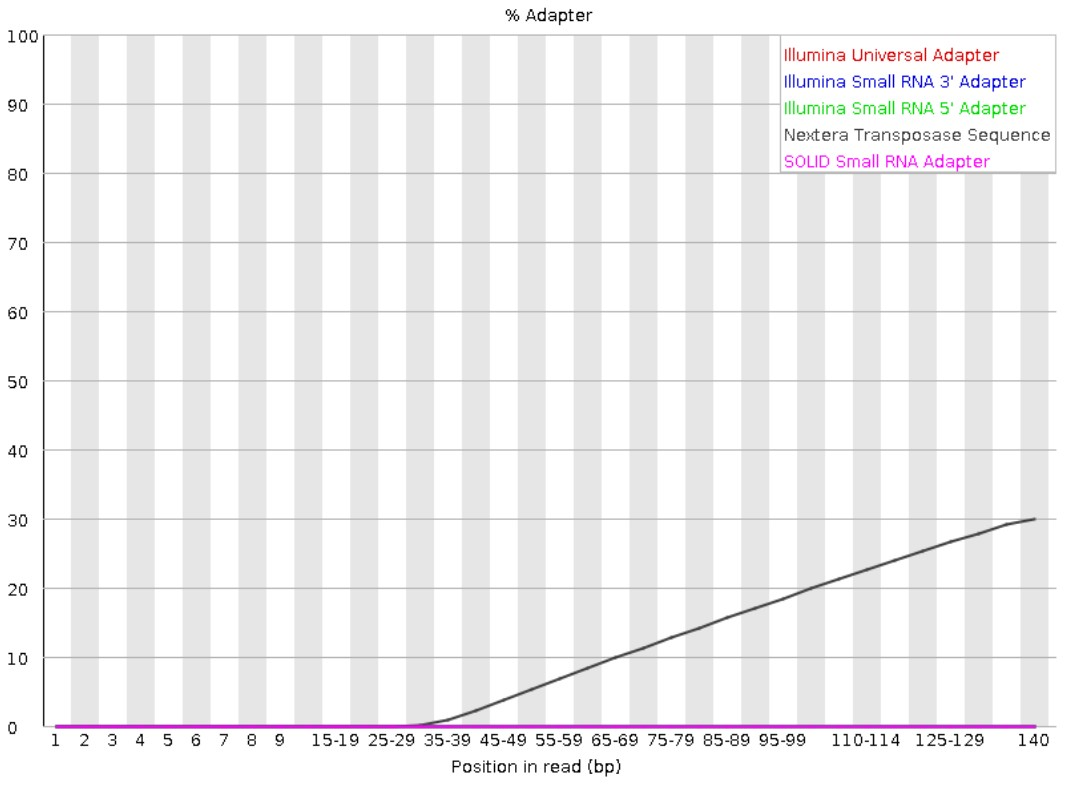

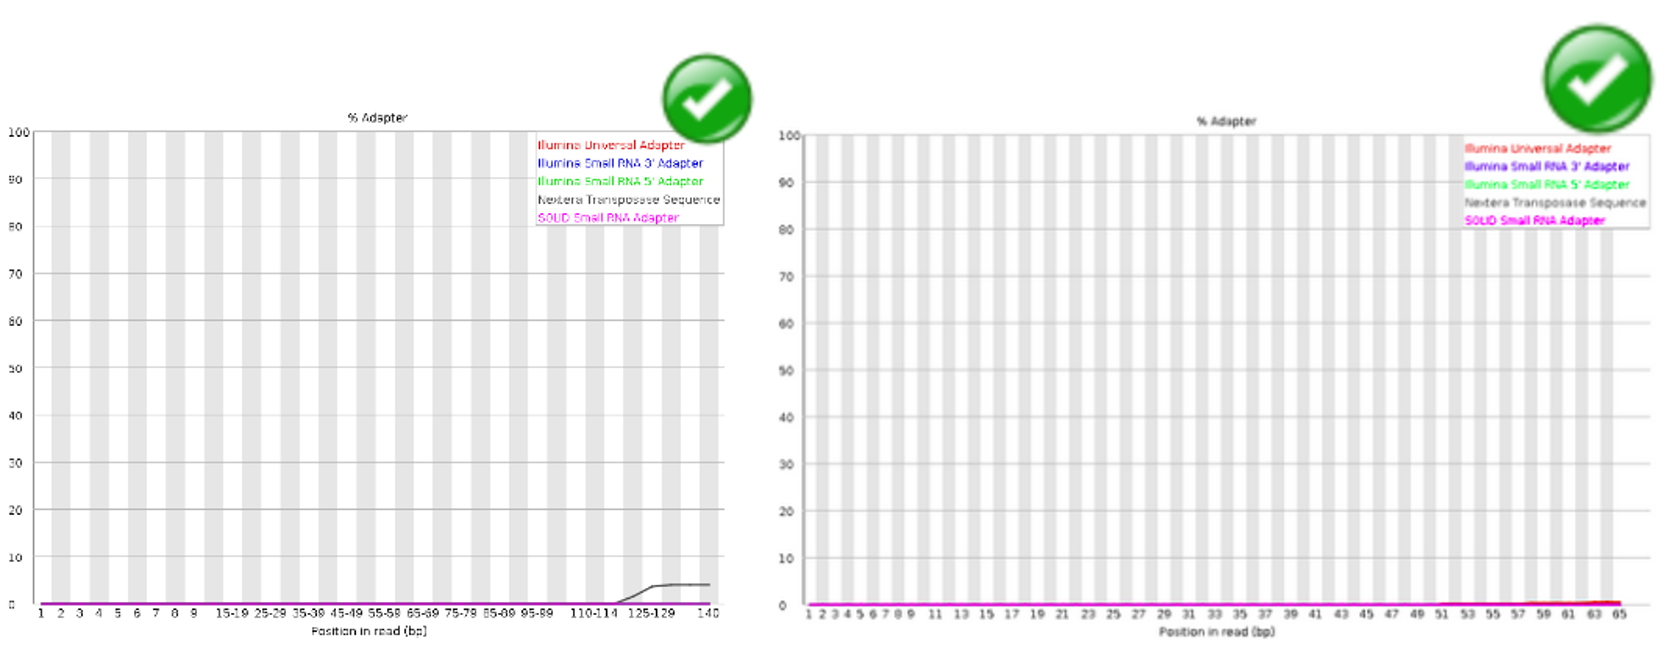

Explication :

Le module "Adapter content" sert à détecter la présence de séquences d'adaptateurs dans vos reads. Les séquences d'adaptateurs sont des fragments d'ADN ajoutés aux lectures pour faciliter le processus de séquençage, mais elles ne devraient pas être présentes dans les lectures finales.

FastQC recherche donc des séquences spécifiques d'adaptateurs définies dans une configuration.

Le graphique montre le pourcentage cumulé de reads qui contiennent ces séquences d'adaptateurs à chaque position.

Ce graphique vous aide à déterminer si vous devez effectuer une suppression des adaptateurs (trimming) avant de poursuivre l'analyse de votre séquençage.

<div class="alert alert-block alert-warning">
Ce module émet un avertissement si n'importe quelle séquence est présente dans plus de 5% des reads.
</div>

<div class="alert alert-block alert-danger">
Ce module signalera une erreur si n'importe quelle séquence est présente dans plus de 10% des reads.
</div>